In [1]:
import sys
sys.path.append('../satclip')

import torch
from load import get_satclip

/opt/anaconda3/envs/rishabh_sat/lib/python3.12/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
from huggingface_hub import hf_hub_download
from load import get_satclip
import torch

device = "cuda:1" if torch.cuda.is_available() else "cpu"

c = torch.randn(32, 2)  # Represents a batch of 32 locations (lon/lat)

model = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ViT16-L10", "satclip-vit16-l10.ckpt"),
    device=device,
)  # Only loads location encoder by default
model.eval()
with torch.no_grad():
    emb = model(c.double().to(device)).detach().cpu()


using pretrained moco vit16


In [3]:
emb

tensor([[ 0.8704,  2.3571,  2.5905,  ..., -0.7382, -1.5582, -0.0207],
        [ 0.8748,  2.2187,  2.8891,  ..., -0.5256, -1.5413, -0.0988],
        [ 0.9307,  2.0679,  3.0463,  ..., -0.4284, -1.5727, -0.1355],
        ...,
        [ 0.9305,  1.6840,  3.0482,  ..., -0.4030, -1.8301, -0.0825],
        [ 1.1505,  1.2132,  3.0951,  ..., -0.4010, -1.9698,  0.0061],
        [ 0.8693,  1.8494,  2.9180,  ..., -0.4863, -1.7797, -0.0698]],
       dtype=torch.float64)

In [4]:
#for my location 
import pandas as pd
import torch
from huggingface_hub import hf_hub_download
from load import get_satclip

# Load coordinates
df = pd.read_csv("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/india_bangladesh_pakisthan_images/index.csv")
coords = torch.tensor(df[["lon", "lat"]].values, dtype=torch.float64)  # (N, 2)

# Load model
# device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = hf_hub_download("microsoft/SatCLIP-ViT16-L10", "satclip-vit16-l10.ckpt")
model = get_satclip(model_path, device=device)  # only location encoder by default
model.eval()

# Compute embeddings
with torch.no_grad():
    embeddings = model(coords.to(device)).detach().cpu()  # (N, D)


using pretrained moco vit16


In [5]:
embeddings.shape  # Should be (N, D) where D is the embedding dimension

torch.Size([336730, 256])

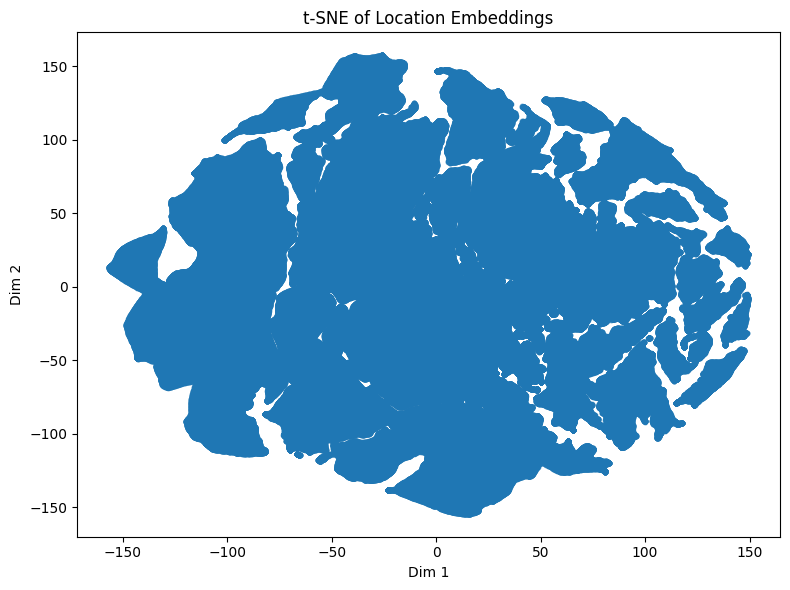

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce embedding to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(embeddings.numpy())

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE of Location Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()
